# Test Repair Verification

Compares the test-repair agent's verdicts with what actually happened to the push:
whether it was backed out on hg, how sheriffs classified the failing job on
Treeherder, and how long after the sheriff the agent finished.

Data sources, all public except the first:

- hackbot-api `GET /runs` (needs `HACKBOT_API_URL` and `HACKBOT_API_KEY`)
- Taskcluster queue for the task's project and hg revision, as `resolve.py` does
- Treeherder API for the job and its classification notes
- hg.mozilla.org `json-pushes` for the pushlog and the backouts in it

In [ ]:
%%sql


In [17]:
from dotenv import load_dotenv

load_dotenv()

True

## Setup

In [18]:
import json
import logging
import os
import re
import threading
import time
from concurrent.futures import ThreadPoolExecutor
from functools import lru_cache
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import requests
from matplotlib.ticker import MaxNLocator

HACKBOT_API_URL = os.environ["HACKBOT_API_URL"].rstrip("/")
HACKBOT_API_KEY = os.environ["HACKBOT_API_KEY"]
AGENT = "test-repair"
# Runs younger than this may not have been backed out or classified yet.
MIN_AGE = pd.Timedelta(hours=24)
# hg.mozilla.org answers 406 to bursts of requests and then refuses the client for a
# while, so its calls are serialized and spaced out.
HG_MIN_INTERVAL = 1.0
# Taskcluster and hg answers are cached on disk. A backout can still land for a
# recent push, so a day of pushlog is cached only once it is this old.
CACHE_PATH = Path.home() / ".cache" / "test_repair_verification.json"
CACHE_MIN_AGE = pd.Timedelta(days=7)

TASKCLUSTER = "https://firefox-ci-tc.services.mozilla.com/api/queue/v1/task"
TREEHERDER = "https://treeherder.mozilla.org/api/project"
HG = "https://hg.mozilla.org"
HG_REPO_PATHS = {
    "autoland": "integration/autoland",
    "mozilla-central": "mozilla-central",
    "mozilla-beta": "releases/mozilla-beta",
    "mozilla-release": "releases/mozilla-release",
}
# https://treeherder.mozilla.org/api/failureclassification/
CLASSIFICATIONS = {
    1: "not classified",
    2: "fixed by commit",
    3: "expected fail",
    4: "intermittent",
    5: "infra",
    6: "new failure not classified",
    7: "autoclassified intermittent",
    8: "intermittent needs bugid",
}

logging.basicConfig(level=logging.WARNING, format="%(asctime)s %(message)s")
session = requests.Session()
session.headers["User-Agent"] = "bugbug-test-repair-verification/1.0"
RETRY_STATUSES = {406, 429}


def get_json(url, headers=None, retries=7):
    for attempt in range(retries):
        try:
            resp = session.get(url, headers=headers, timeout=60)
        except requests.ConnectionError:
            resp = None
        if resp is not None:
            if resp.status_code in (400, 404):
                return None
            if resp.status_code < 400:
                return resp.json()
            if resp.status_code < 500 and resp.status_code not in RETRY_STATUSES:
                resp.raise_for_status()
        wait = 5 * 2**attempt
        status = resp.status_code if resp is not None else "connection error"
        logging.warning("%s -> %s, retrying in %ss", url, status, wait)
        time.sleep(wait)
    raise RuntimeError(f"gave up on {url}")


cache = json.loads(CACHE_PATH.read_text()) if CACHE_PATH.exists() else {}
_cache_lock = threading.Lock()


def cached_json(url, fetch=get_json, cacheable=lambda data: True):
    if url in cache:
        return cache[url]
    data = fetch(url)
    if data is not None and cacheable(data):
        with _cache_lock:
            cache[url] = data
    return data


def save_cache():
    CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    CACHE_PATH.write_text(json.dumps(cache))


_hg_lock = threading.Lock()
_hg_last_request = [0.0]


def hg_json(url):
    with _hg_lock:
        wait = _hg_last_request[0] + HG_MIN_INTERVAL - time.monotonic()
        if wait > 0:
            time.sleep(wait)
        _hg_last_request[0] = time.monotonic()
    return get_json(url)


def fetch_all(func, keys, workers=8):
    keys = list(dict.fromkeys(keys))
    with ThreadPoolExecutor(workers) as pool:
        return {k: v for k, v in zip(keys, pool.map(func, keys)) if v is not None}


def join_lookup(df, lookups, key_cols):
    if not lookups:
        return df
    extra = pd.DataFrame.from_dict(lookups, orient="index")
    if len(key_cols) > 1:
        extra.index = pd.MultiIndex.from_tuples(extra.index)
    return df.join(extra, on=key_cols)

## Load runs from hackbot-api

In [19]:
def iter_runs(agent, page_size=100):
    headers = {"X-API-Key": HACKBOT_API_KEY}
    offset = 0
    while True:
        page = get_json(
            f"{HACKBOT_API_URL}/runs?agent={agent}&limit={page_size}&offset={offset}",
            headers=headers,
        )
        yield from page
        if len(page) < page_size:
            return
        offset += page_size


def runs_frame(runs):
    rows = []
    for run in runs:
        findings = (run.get("summary") or {}).get("findings") or {}
        failure_tasks = run["inputs"].get("failure_tasks") or {}
        rows.append(
            {
                "run_id": run["run_id"],
                "status": run["status"],
                "created_at": run["created_at"],
                "finished_at": run["updated_at"],
                "task_id": next(iter(failure_tasks.values()), None),
                "classification": findings.get("classification"),
                "recommendation": findings.get("recommendation"),
                "culprit_commit": findings.get("culprit_commit"),
                "candidate_commits": findings.get("candidate_commits") or [],
                "confidence": findings.get("confidence"),
                "last_green_revision": findings.get("last_green_revision"),
            }
        )
    df = pd.DataFrame(rows)
    for col in ("created_at", "finished_at"):
        df[col] = pd.to_datetime(df[col], utc=True)
    df["day"] = df["created_at"].dt.floor("D")
    df["verdict"] = df["classification"].fillna("no verdict") + df[
        "recommendation"
    ].map(lambda r: f" / {r}" if isinstance(r, str) else "")
    return df.sort_values("created_at").reset_index(drop=True)


df = runs_frame(iter_runs(AGENT))
print(
    f"{len(df)} runs from {df.created_at.min():%Y-%m-%d} to {df.created_at.max():%Y-%m-%d}"
)
df["status"].value_counts().to_frame("runs")

687 runs from 2026-07-31 to 2026-09-03


,runs
status,
succeeded,668
failed,19


## Enrich with the push

The task payload carries the hg revision (`GECKO_HEAD_REV`) and the project tag,
which is how the agent itself resolves a task. Treeherder is then queried by task
id, the one identifier that survives the whole pipeline.

In [20]:
@lru_cache(maxsize=None)
def task_push(task_id):
    task = cached_json(f"{TASKCLUSTER}/{task_id}")
    if task is None:
        return None
    return {
        "project": task.get("tags", {}).get("project", "autoland"),
        "hg_revision": task.get("payload", {}).get("env", {}).get("GECKO_HEAD_REV"),
        "task_label": task.get("tags", {}).get("label"),
    }


df = join_lookup(df, fetch_all(task_push, df["task_id"].dropna()), ["task_id"])
save_cache()
df[["project", "hg_revision"]].describe()

,project,hg_revision
count,687,687
unique,1,672
top,autoland,4f8d2e44c95a4d1251d643021073a781326a6618
freq,687,5


## Treeherder: job and sheriff classification

The first note on a job is the sheriff's decision and its `created` timestamp is
when they made it. A job that is still `not classified` was never touched by a
sheriff, so it has no classification time. Jobs are cycled out of Treeherder after
120 days, so old runs have no job. Note timestamps are naive UTC.

In [21]:
@lru_cache(maxsize=None)
def treeherder_job(key):
    project, task_id = key
    results = (get_json(f"{TREEHERDER}/{project}/jobs/?task_id={task_id}") or {}).get(
        "results"
    )
    if not results:
        return None
    job = results[0]
    notes = get_json(f"{TREEHERDER}/{project}/note/?job_id={job['id']}") or []
    first = min(notes, key=lambda n: n["created"], default=None)
    return {
        "job_id": job["id"],
        "push_id": job["push_id"],
        "job_end": pd.Timestamp(job["end_timestamp"], unit="s", tz="UTC"),
        "th_classification": CLASSIFICATIONS.get(job["failure_classification_id"]),
        "sheriff_classified_at": pd.Timestamp(first["created"], tz="UTC")
        if first
        else pd.NaT,
        "sheriff_classification": CLASSIFICATIONS.get(
            first["failure_classification_id"]
        )
        if first
        else None,
        "sheriff_fixed_by": (first or {}).get("text") or None,
    }


job_keys = [k for k in zip(df["project"], df["task_id"]) if k[0] and k[1]]
df = join_lookup(df, fetch_all(treeherder_job, job_keys), ["project", "task_id"])
df["th_classification"].value_counts(dropna=False).to_frame("runs")

,runs
th_classification,
intermittent,281
fixed by commit,211
not classified,170
expected fail,11
infra,6
intermittent needs bugid,5
new failure not classified,3


## hg: was the push backed out?

hg answers bursts of requests with HTTP 406, so instead of one lookup per changeset
the autoland pushlog is fetched once per day for the whole window, from two days
before the first run until now. Backouts are then read from commit messages, the
same `Backed out changeset` and `This reverts commit` lines hg itself uses to derive
`backedoutby`. The pushlog carries each changeset's git sha, which is how the agent's
culprit is matched. Day chunks older than a week are cached on disk.

In [22]:
BACKOUT_RE = re.compile(
    r"(?:Backed out changeset|reverts commit) ([0-9a-f]{12,40})", re.IGNORECASE
)
PUSHLOG_MARGIN = pd.Timedelta(days=2)


def hg_repo(project):
    return f"{HG}/{HG_REPO_PATHS.get(project, project)}"


def pushlog(project, start, end):
    now = pd.Timestamp.now(tz="UTC")
    rows = []
    day = start.floor("D")
    while day < end:
        next_day = day + pd.Timedelta(days=1)
        url = (
            f"{hg_repo(project)}/json-pushes?version=2&full=1"
            f"&startdate={day:%Y-%m-%d %H:%M:%S}&enddate={next_day:%Y-%m-%d %H:%M:%S}"
        )
        data = cached_json(
            url, fetch=hg_json, cacheable=lambda _: next_day < now - CACHE_MIN_AGE
        )
        for push_id, push in (data or {}).get("pushes", {}).items():
            for changeset in push["changesets"]:
                rows.append(
                    {
                        "project": project,
                        "push_id": int(push_id),
                        "push_time": pd.Timestamp(push["date"], unit="s", tz="UTC"),
                        "node": changeset["node"],
                        "git_node": changeset.get("git_node"),
                        "desc": changeset["desc"],
                    }
                )
        day = next_day
    return pd.DataFrame(rows)


window_start = df["created_at"].min() - PUSHLOG_MARGIN
changesets = pd.concat(
    [
        pushlog(project, window_start, pd.Timestamp.now(tz="UTC"))
        for project in df["project"].dropna().unique()
    ],
    ignore_index=True,
)
save_cache()

by_prefix = {node[:12]: node for node in changesets["node"]}
by_git = dict(zip(changesets["git_node"], changesets["node"]))


def backed_out_nodes(desc):
    for sha in BACKOUT_RE.findall(desc):
        sha = sha.lower()
        yield by_git.get(sha) or by_prefix.get(sha[:12])


backout_time = {}
for row in changesets.itertuples():
    for node in backed_out_nodes(row.desc):
        if node and row.push_time < backout_time.get(
            node, pd.Timestamp.max.tz_localize("UTC")
        ):
            backout_time[node] = row.push_time

changesets["backout_time"] = changesets["node"].map(backout_time)
changesets["push_backout_time"] = changesets.groupby(["project", "push_id"])[
    "backout_time"
].transform("min")
print(
    f"{len(changesets)} changesets, {changesets['backout_time'].notna().sum()} backed out"
)

node_info = changesets.set_index("node")[["push_id", "push_time", "push_backout_time"]]
node_info = node_info.rename(
    columns={"push_id": "hg_push_id", "push_backout_time": "backout_time"}
)
df = df.join(node_info, on="hg_revision")
df["push_backed_out"] = df["backout_time"].notna().where(df["hg_push_id"].notna())

culprits = changesets.dropna(subset=["git_node"]).set_index("git_node")["backout_time"]
in_window = df["culprit_commit"].isin(culprits.index)
df["culprit_backed_out"] = pd.Series(pd.NA, index=df.index, dtype="boolean")
df.loc[in_window, "culprit_backed_out"] = (
    df.loc[in_window, "culprit_commit"].map(culprits).notna()
)
df["push_backed_out"].value_counts(dropna=False).to_frame("runs")

8006 changesets, 827 backed out


,runs
push_backed_out,
False,562
True,125


## Scoring

The sheriff's classification of the failing job is the ground truth when there is
one: `fixed by commit` means a regression, an intermittent, expected-fail or infra
classification means not a regression. A push can be backed out for an unrelated
failure, so the hg backout only decides the runs the sheriff never classified.
`decision_correct` compares the agent's classification with that. `culprit_correct`
is stricter: the commit the agent blamed was backed out.

`delay_min` is how many minutes after the sheriff's first classification the agent
finished. Negative means the agent was first.

In [23]:
INTERMITTENT_CLASSIFICATIONS = {
    "intermittent",
    "autoclassified intermittent",
    "intermittent needs bugid",
    "expected fail",
    "infra",
}

hg_regression = df["push_backed_out"].fillna(False) | df["culprit_backed_out"].fillna(
    False
)
sheriff = df["sheriff_classification"]
df["ground_truth"] = "hg"
df["actual_regression"] = hg_regression
df.loc[
    sheriff.isin(INTERMITTENT_CLASSIFICATIONS), ["ground_truth", "actual_regression"]
] = ["sheriff", False]
df.loc[sheriff == "fixed by commit", ["ground_truth", "actual_regression"]] = [
    "sheriff",
    True,
]

df["settled"] = (pd.Timestamp.now(tz="UTC") - df["created_at"]) > MIN_AGE
scorable = df["classification"].notna() & df["push_backed_out"].notna()
agent_regression = df["classification"] == "regression"
df["decision_correct"] = pd.NA
df.loc[scorable, "decision_correct"] = (agent_regression == df["actual_regression"])[
    scorable
]
df["culprit_correct"] = df["culprit_backed_out"].where(df["culprit_commit"].notna())
df["delay_min"] = (
    df["finished_at"] - df["sheriff_classified_at"]
).dt.total_seconds() / 60
df["agent_after_job_end_min"] = (
    df["finished_at"] - df["job_end"]
).dt.total_seconds() / 60
df["sheriff_after_job_end_min"] = (
    df["sheriff_classified_at"] - df["job_end"]
).dt.total_seconds() / 60

scored = df[df["settled"] & scorable]
hg_only_correct = (agent_regression == hg_regression)[scored.index]
print(f"{len(scored)} settled runs with a verdict and hg data")
print(f"decision accuracy: {scored['decision_correct'].mean():.1%}")
print(f"decision accuracy against hg backouts alone: {hg_only_correct.mean():.1%}")
regressions = scored[scored["classification"] == "regression"]
print(
    f"culprit accuracy on regression verdicts: {regressions['culprit_correct'].mean():.1%}"
)
pd.crosstab(
    scored["verdict"],
    [
        scored["ground_truth"],
        scored["actual_regression"].map(
            {True: "regression", False: "not a regression"}
        ),
    ],
)

639 settled runs with a verdict and hg data
decision accuracy: 87.6%
decision accuracy against hg backouts alone: 84.7%
culprit accuracy on regression verdicts: 83.6%


ground_truth                                hg                     sheriff  \
actual_regression             not a regression regression not a regression   
verdict                                                                      
intermittent / do_not_backout              102         10              170   
intermittent / rerun                        36          0               70   
regression / backout                         2          7               16   
regression / do_not_backout                  1          0                1   
regression / land_fix                        3          4               10   
regression / rerun                           2          0                3   

ground_truth                              
actual_regression             regression  
verdict                                   
intermittent / do_not_backout         16  
intermittent / rerun                  15  
regression / backout                 136  
regression / do_not_backout            6  
regression / land_fix                 23  
regression / rerun                     6

In [24]:
pd.Series(
    {
        "runs": len(df),
        "with task id": df["task_id"].notna().sum(),
        "with hg revision": df["hg_revision"].notna().sum(),
        "with Treeherder job": df["job_id"].notna().sum(),
        "with sheriff note": df["sheriff_classified_at"].notna().sum(),
        "with hg push data": df["push_backed_out"].notna().sum(),
        "with verdict": df["classification"].notna().sum(),
        "settled": df["settled"].sum(),
        "scored": len(scored),
    },
    name="runs",
).to_frame()

,runs
runs,687
with task id,687
with hg revision,687
with Treeherder job,687
with sheriff note,509
with hg push data,687
with verdict,668
settled,658
scored,639


In [25]:
df[df["delay_min"].notna()][
    ["delay_min", "agent_after_job_end_min", "sheriff_after_job_end_min"]
].describe()

,delay_min,agent_after_job_end_min,sheriff_after_job_end_min
count,509.000000,509.000000,509.000000
mean,50.887544,92.028172,41.140628
std,721.927347,717.580349,76.691168
min,-1222.357056,9.414684,1.348148
25%,-11.591716,18.725976,16.294866
50%,1.338516,27.344685,26.582689
75%,7.470097,36.817543,42.609755
max,14609.319255,14651.496490,1249.768433


In [26]:
df

,run_id,status,created_at,finished_at,task_id,classification,recommendation,culprit_commit,candidate_commits,confidence,...,push_backed_out,culprit_backed_out,ground_truth,actual_regression,settled,decision_correct,culprit_correct,delay_min,agent_after_job_end_min,sheriff_after_job_end_min
0,faa67b9c-2e99-49c2-af06-857e8d968bf5,failed,2026-07-31 18:11:49.966022+00:00,2026-07-31 18:11:49.966022+00:00,TubbtE9YT8KWh_B_p-824g,NaN,NaN,NaN,[],NaN,...,False,<NA>,sheriff,False,True,<NA>,<NA>,-21.327606,20.249434,41.577040
1,d9c9a289-6f4e-43ae-a92f-2dae7eb68a5f,failed,2026-07-31 18:16:55.122471+00:00,2026-07-31 18:16:55.122471+00:00,RLPLLt9wThC5exBv4SZ2rA,NaN,NaN,NaN,[],NaN,...,True,<NA>,hg,True,True,<NA>,<NA>,NaN,45.685375,NaN
2,e2f19451-bcb1-4667-b525-48a9288e1ad0,failed,2026-07-31 18:19:29.026348+00:00,2026-07-31 18:19:29.026348+00:00,Qr33OJmmQ9qUUgFdg8Pldg,NaN,NaN,NaN,[],NaN,...,False,<NA>,hg,False,True,<NA>,<NA>,NaN,48.550439,NaN
3,51fef27e-e333-4aad-bba3-f239f8b403ad,failed,2026-07-31 18:32:48.007022+00:00,2026-07-31 18:32:48.007022+00:00,b-jTG0_WSvi7Wo9a-ZeO4A,NaN,NaN,NaN,[],NaN,...,False,<NA>,hg,False,True,<NA>,<NA>,NaN,60.783450,NaN
4,7fbfed04-c41e-44a9-8b4c-ca9db5786b76,failed,2026-07-31 18:38:19.266440+00:00,2026-07-31 18:38:19.266440+00:00,KO-kPciESeanLk1Cz2kn8w,NaN,NaN,NaN,[],NaN,...,False,<NA>,hg,False,True,<NA>,<NA>,NaN,59.721107,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
682,13f70d66-26cc-40b2-a4e9-b91133dafd42,succeeded,2026-09-03 19:39:20.810116+00:00,2026-09-03 19:48:33.795977+00:00,HJaC3e3TTnePFZ7mYKkx2Q,intermittent,do_not_backout,NaN,[],0.85,...,False,<NA>,hg,False,False,True,<NA>,NaN,163.579933,NaN
683,9e53f4fb-e8ad-464e-bc49-ced6ac32a4bf,succeeded,2026-09-03 19:48:38.633745+00:00,2026-09-03 19:59:30.117236+00:00,BZ1tUgUATl-U-KNHUxEgMA,intermittent,do_not_backout,NaN,[],0.65,...,False,<NA>,sheriff,False,False,True,<NA>,4.282894,21.051954,16.769059
684,6dd68673-7e8e-44b4-a3c7-f5a8fca9671d,succeeded,2026-09-03 20:19:23.041433+00:00,2026-09-03 20:28:17.881025+00:00,LJwrntlUTMi_YcF6F-GHXQ,intermittent,do_not_backout,NaN,[],0.85,...,False,<NA>,sheriff,False,False,True,<NA>,8.066536,9.414684,1.348148
685,9d03cca8-08c4-45fe-a9f8-6f0fb3b9f91c,succeeded,2026-09-03 21:09:52.689737+00:00,2026-09-03 21:19:22.446671+00:00,d8mH6gbdTuyfjwPlj2ct0Q,intermittent,do_not_backout,NaN,[],0.90,...,False,<NA>,sheriff,False,False,True,<NA>,-0.294109,20.440778,20.734887


## Charts

In [27]:
PALETTE = [
    "#2a78d6",
    "#eb6834",
    "#1baf7a",
    "#eda100",
    "#e87ba4",
    "#4a3aa7",
    "#008300",
    "#e34948",
]
CORRECT_COLORS = {"correct": "#008300", "incorrect": "#e34948"}


def verdict_colors(verdicts):
    colors = dict(zip(sorted(v for v in verdicts if v != "no verdict"), PALETTE))
    colors["no verdict"] = "#9e9d98"
    return colors


def style(ax, title, ylabel, integer_y=True):
    ax.set_title(title, loc="left", fontsize=12)
    ax.set_ylabel(ylabel)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#e5e4e0", linewidth=0.8)
    ax.set_axisbelow(True)
    span_days = max(1, int(ax.get_xlim()[1] - ax.get_xlim()[0]))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=max(1, span_days // 15)))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    if integer_y:
        ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.01, 1))


def stacked_days(ax, counts, colors):
    bottom = pd.Series(0, index=counts.index)
    for column in colors:
        if column not in counts:
            continue
        ax.bar(
            counts.index,
            counts[column],
            bottom=bottom,
            color=colors[column],
            edgecolor="white",
            linewidth=2,
            label=column,
            width=0.8,
        )
        bottom = bottom + counts[column]

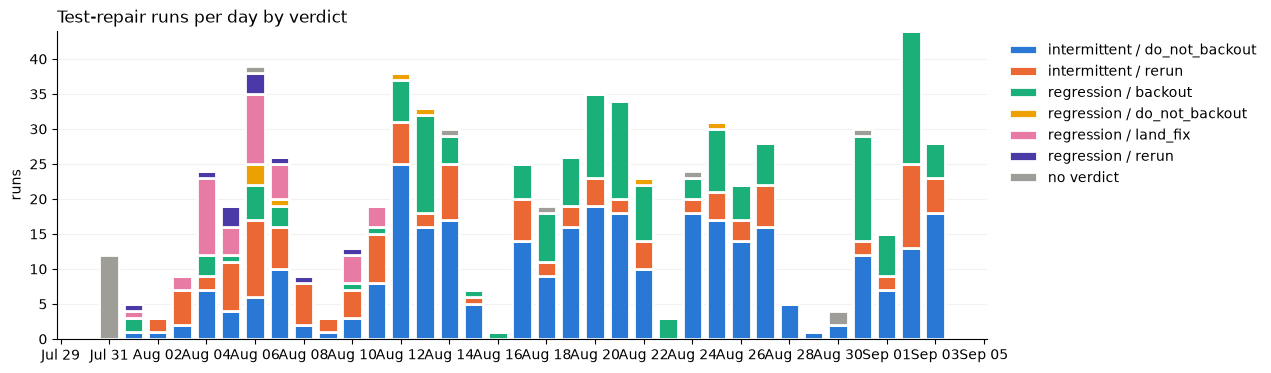

In [28]:
per_day = pd.crosstab(df["day"], df["verdict"])
fig, ax = plt.subplots(figsize=(12, 4))
stacked_days(ax, per_day, verdict_colors(per_day.columns))
style(ax, "Test-repair runs per day by verdict", "runs")
plt.show()

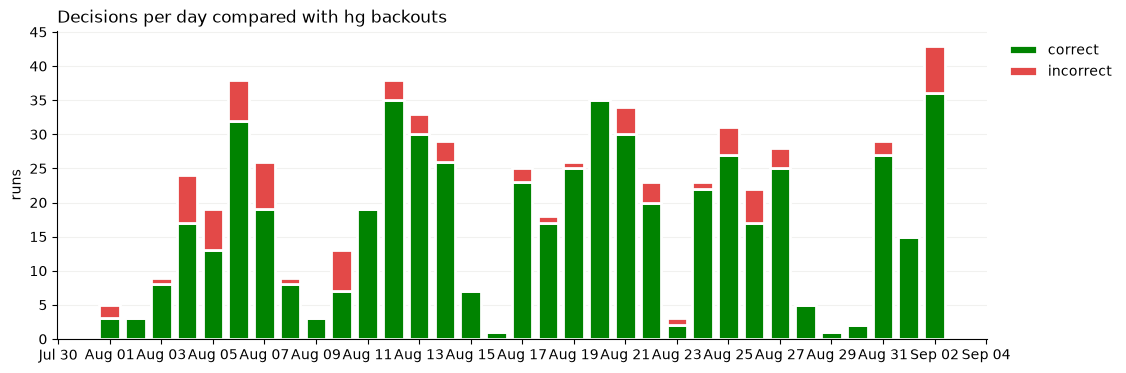

In [29]:
outcome = scored["decision_correct"].map({True: "correct", False: "incorrect"})
per_day = pd.crosstab(scored["day"], outcome)
fig, ax = plt.subplots(figsize=(12, 4))
stacked_days(ax, per_day, CORRECT_COLORS)
style(ax, "Decisions per day compared with hg backouts", "runs")
plt.show()

## Latency

Three measures, all in minutes. Runs that finished more than `LIVE_MAX_HOURS` after
the job ended were replays of old failures, not live decisions, and are left out
along with the 1st and 99th percentile tails of the agent-to-sheriff delay.
Jobs the sheriff never classified have no delay.

In [30]:
LIVE_MAX_HOURS = 12
OUTLIER_QUANTILES = (0.01, 0.99)

timed = df[df["delay_min"].notna()]
live = timed["agent_after_job_end_min"] < LIVE_MAX_HOURS * 60
low, high = timed.loc[live, "delay_min"].quantile(OUTLIER_QUANTILES)
in_range = timed["delay_min"].between(low, high)
print(
    f"{(~live).sum()} replayed runs and {(live & ~in_range).sum()} outliers outside "
    f"[{low:.0f}, {high:.0f}] minutes left out of {len(timed)}"
)
timed = timed[live & in_range]
daily = timed.groupby("day").agg(
    runs=("delay_min", "size"),
    mean_delay=("delay_min", "mean"),
    median_delay=("delay_min", "median"),
    agent_after_job_end=("agent_after_job_end_min", "mean"),
    sheriff_after_job_end=("sheriff_after_job_end_min", "mean"),
)
pd.DataFrame(
    {
        "mean": timed[
            ["delay_min", "agent_after_job_end_min", "sheriff_after_job_end_min"]
        ].mean(),
        "median": timed[
            ["delay_min", "agent_after_job_end_min", "sheriff_after_job_end_min"]
        ].median(),
    }
).round(1).assign(agent_first=[f"{(timed['delay_min'] < 0).mean():.0%}", "", ""])

4 replayed runs and 12 outliers outside [-248, 344] minutes left out of 509


,mean,median,agent_first
delay_min,2.7,1.0,46%
agent_after_job_end_min,37.3,26.9,
sheriff_after_job_end_min,34.5,26.0,


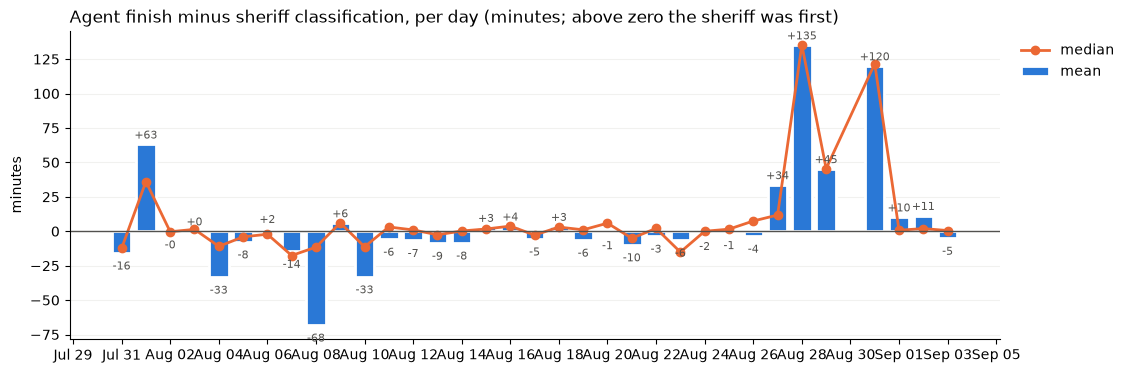

In [31]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(
    daily.index,
    daily["mean_delay"],
    width=0.8,
    color="#2a78d6",
    edgecolor="white",
    linewidth=2,
    label="mean",
)
ax.plot(
    daily.index,
    daily["median_delay"],
    color="#eb6834",
    linewidth=2,
    marker="o",
    markersize=6,
    label="median",
)
for day, value in daily["mean_delay"].items():
    ax.annotate(
        f"{value:+.0f}",
        (day, value),
        textcoords="offset points",
        xytext=(0, 4 if value >= 0 else -12),
        ha="center",
        fontsize=8,
        color="#52514e",
    )
ax.axhline(0, color="#52514e", linewidth=1)
style(
    ax,
    "Agent finish minus sheriff classification, per day (minutes; above zero the sheriff was first)",
    "minutes",
    integer_y=False,
)
plt.show()

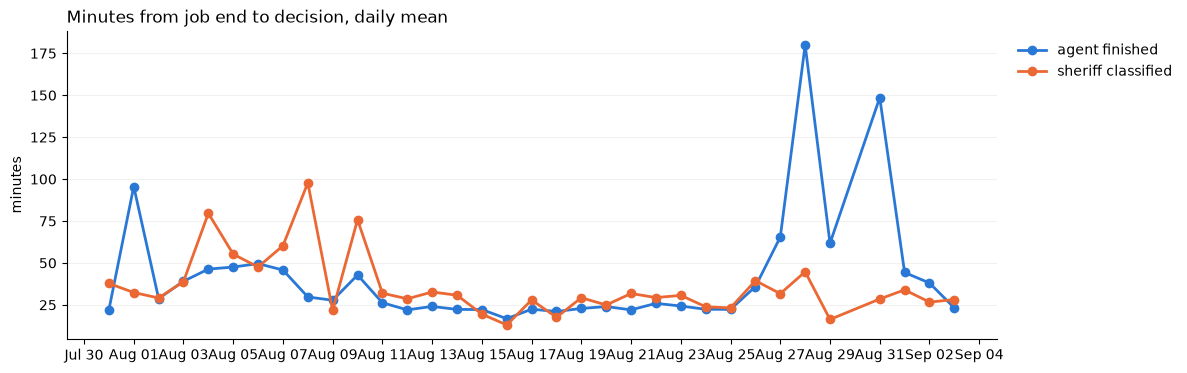

In [32]:
fig, ax = plt.subplots(figsize=(12, 4))
for column, label, color in (
    ("agent_after_job_end", "agent finished", "#2a78d6"),
    ("sheriff_after_job_end", "sheriff classified", "#eb6834"),
):
    ax.plot(
        daily.index,
        daily[column],
        color=color,
        linewidth=2,
        marker="o",
        markersize=6,
        label=label,
    )
style(ax, "Minutes from job end to decision, daily mean", "minutes", integer_y=False)
plt.show()

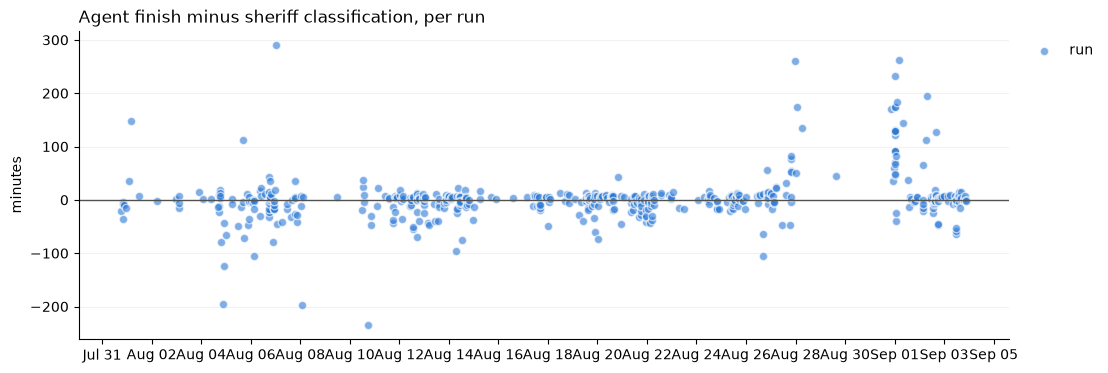

In [33]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.scatter(
    timed["finished_at"],
    timed["delay_min"],
    s=36,
    color="#2a78d6",
    alpha=0.6,
    edgecolor="white",
    linewidth=1,
    label="run",
)
ax.axhline(0, color="#52514e", linewidth=1)
style(
    ax, "Agent finish minus sheriff classification, per run", "minutes", integer_y=False
)
plt.show()

## Disagreements to inspect

In [34]:
columns = [
    "created_at",
    "verdict",
    "confidence",
    "th_classification",
    "sheriff_fixed_by",
    "push_backed_out",
    "culprit_backed_out",
    "project",
    "hg_revision",
    "culprit_commit",
]
scored[~scored["decision_correct"].astype(bool)][columns]

,created_at,verdict,confidence,th_classification,sheriff_fixed_by,push_backed_out,culprit_backed_out,project,hg_revision,culprit_commit
12,2026-08-01 01:11:51.644390+00:00,regression / backout,0.95,intermittent,NaN,False,False,autoland,5ac4db2dbec030af27053da68386f598c5271089,6c2bf8c9d302ad2522e58aa83f180c2925d25290
15,2026-08-01 08:53:59.406195+00:00,regression / rerun,0.75,not classified,NaN,False,<NA>,autoland,6007b8a8df956cc56cfd46a74667ea140445318c,NaN
26,2026-08-03 20:36:28.838479+00:00,regression / land_fix,0.80,not classified,NaN,False,<NA>,autoland,e01239f050e3c6ca58cd8602dfacebb2708ab521,NaN
35,2026-08-04 16:32:18.109868+00:00,regression / land_fix,0.80,intermittent,,True,<NA>,autoland,4e24b68e0bfb208f35c94dce2ca869526b329fcf,NaN
38,2026-08-04 16:54:39.900980+00:00,intermittent / do_not_backout,0.85,not classified,NaN,True,<NA>,autoland,cc5606df5c790a32ebb30f502646ab8542632732,NaN
...,...,...,...,...,...,...,...,...,...,...
641,2026-09-02 15:27:10.723733+00:00,intermittent / rerun,0.85,fixed by commit,9afc778e8e1cb4535a1fd7ccd315c2e1ded5feab,False,<NA>,autoland,a62938eb1762e1e23e9bd120b74c113d9698ac5f,NaN
643,2026-09-02 15:31:06.229067+00:00,intermittent / rerun,0.75,fixed by commit,9afc778e8e1cb4535a1fd7ccd315c2e1ded5feab,True,<NA>,autoland,81d1b8b4cb34cc6da0bffb39de48dfd1d7dee2ed,NaN
645,2026-09-02 17:42:23.212703+00:00,intermittent / do_not_backout,0.75,fixed by commit,00a98c65a6aea95d550c9218cfcee3be784d5112,False,<NA>,autoland,5ae90da4f5b0351e5dc05730ec522ece66c2dbd4,NaN
647,2026-09-02 17:50:26.264648+00:00,regression / backout,0.95,intermittent,NaN,False,True,autoland,2cae0494cd0e3c9c2fe34deda148554473016626,5e2141707d45273bbff77d583f59f6b5158857df
